In [ ]:
pip install git+https://github.com/ssut/py-hanspell.git

  Cloning https://github.com/ssut/py-hanspell.git to /tmp/pip-req-build-t64bfl6n
  Running command git clone --filter=blob:none --quiet https://github.com/ssut/py-hanspell.git /tmp/pip-req-build-t64bfl6n
  Resolved https://github.com/ssut/py-hanspell.git to commit fdc6ca50c19f1c85971437a072d89d4e5ce024b8
  Preparing metadata (setup.py) ... done
  Created wheel for py-hanspell: filename=py_hanspell-1.1-py3-none-any.whl size=4812 sha256=455964c42641f2808b7c26274965ef2d356f23b31a0820829c9f58161204e3ea
  Stored in directory: /tmp/pip-ephem-wheel-cache-hw34q7cg/wheels/17/cd/d3/1046f3c4c2ee945775e6f1585962648813dbeda3a69f5b2b63
Successfully built py-hanspell


# ★ 데이터 클렌징 시작 ★

In [1]:
# 기본 라이브러리만 임포트 (설치 불필요)
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Pandas 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("✅ 환경 설정 완료 (외부 설치 없음)")
print(f"Python 버전: {pd.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

✅ 환경 설정 완료 (외부 설치 없음)
Python 버전: 2.2.2
Pandas: 2.2.2
NumPy: 2.0.2


In [2]:
CONFIG = {
    'steps': {
        'remove_emoji': True,
        'normalize_repeat': True,
        'correct_spacing': False,  # 외부 API 불필요 - 규칙 기반으로 처리
        'correct_typo': True,
        'quality_analysis': True,
    },
    'emoji': {
        'remove_unicode_emoji': True,
        'remove_emoticons': True,
    },
    'repeat': {
        'mode': 'reduce',
        'max_repeat': 0, # 단일 모음/자음 비허용
        'target_chars': ['ㅋ', 'ㅎ', 'ㄷ', 'ㅠ', 'ㅜ', 'ㅡ', '~', '!', '?', '.'],
    },
    'spacing': {
        'use_basic_rules': True,  # 규칙 기반 띄어쓰기
    },
    'typo': {
        'use_domain_dict': True,
    },
    'quality': {
        'min_length': 10,
        'min_korean_ratio': 0.3,
        'quality_threshold': 0.3,
        'filter_low_quality': False,
    },
    'logging': {
        'sample_size': 200,
        'random_seed': 42,
    },
}

DOMAIN_DICT = {
    '토너': ['토나', '토넝'],
    '로션': ['로숀', '로선'],
    '세럼': ['세험'],
    '크림': ['끌림'],
    '클렌징': ['크랜징'],
    '보습': ['보슴'],
    '흡수': ['흡수'],
    '발림성': ['발림성'],
    '끈적임': ['끈척임'],
}

print("✅ Configuration 설정 완료")

✅ Configuration 설정 완료


In [3]:
class PipelineLogger:
    def __init__(self):
        self.logs = []
        self.start_time = datetime.now()

    def log_step(self, step_name, df_before, df_after, column='clean_text', **kwargs):
        before_texts = df_before[column].fillna('')
        after_texts = df_after[column].fillna('')

        changed = (before_texts != after_texts).sum()
        changed_ratio = changed / len(df_before) * 100

        avg_len_before = before_texts.str.len().mean()
        avg_len_after = after_texts.str.len().mean()
        len_change = avg_len_after - avg_len_before

        log_entry = {
            'step': step_name,
            'rows_changed': int(changed),
            'change_ratio': f"{changed_ratio:.2f}%",
            'avg_length_before': f"{avg_len_before:.1f}",
            'avg_length_after': f"{avg_len_after:.1f}",
            'length_change': f"{len_change:+.1f}",
            **kwargs
        }

        self.logs.append(log_entry)

        print(f"\n{'='*60}")
        print(f"📊 {step_name}")
        print(f"{'='*60}")
        print(f"변경: {changed:,} / {len(df_before):,} ({changed_ratio:.2f}%)")
        print(f"평균 길이: {avg_len_before:.1f} → {avg_len_after:.1f} ({len_change:+.1f})")
        for k, v in kwargs.items():
            print(f"{k}: {v}")

    def get_summary(self):
        return pd.DataFrame(self.logs)


def compute_text_stats(texts):
    # 리뷰 문장 분석
    texts = texts.fillna('')
    stats = {
        'length': texts.str.len(),
        'korean_chars': texts.str.count('[가-힣]'),
        'spaces': texts.str.count(' '),
        'special_chars': texts.str.count('[^가-힣a-zA-Z0-9\\s]'),
    }
    stats_df = pd.DataFrame(stats)
    stats_df['korean_ratio'] = np.where(
        stats_df['length'] > 0,
        stats_df['korean_chars'] / stats_df['length'],
        0
    )
    stats_df['space_ratio'] = np.where(
        stats_df['length'] > 0,
        stats_df['spaces'] / stats_df['length'],
        0
    )
    stats_df['special_ratio'] = np.where(
        stats_df['length'] > 0,
        stats_df['special_chars'] / stats_df['length'],
        0
    )
    return stats_df


print("✅ 유틸리티 함수 정의 완료")

✅ 유틸리티 함수 정의 완료


In [4]:
def remove_emoji_step(df, config, logger):
    if not config['steps']['remove_emoji']:
        print("⏭️  Step 1 SKIP")
        return df

    df_result = df.copy()

    def clean_emoji(text):
        if pd.isna(text) or text == '':
            return text

        # 이모지 유니코드 범위 (라이브러리 없이 정규식만 사용)
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # Emoticons
            "\U0001F300-\U0001F5FF"  # Symbols & Pictographs
            "\U0001F680-\U0001F6FF"  # Transport & Map
            "\U0001F1E0-\U0001F1FF"  # Flags
            "\U0001F900-\U0001F9FF"  # Supplemental Symbols
            "\U00002600-\U000026FF"  # Miscellaneous Symbols
            "\U00002700-\U000027BF"  # Dingbats
            "]+"
        )
        text = emoji_pattern.sub(' ', text)

        # ASCII 이모티콘
        text = re.sub(r':\)|;\)|:D|:P|:\(|:/', ' ', text)
        text = re.sub(r'\^\^', ' ', text)

        # 연속 공백
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    print("\n처리 중...")
    df_result['clean_text'] = df_result['clean_text'].apply(clean_emoji)

    logger.log_step("Step 1: 이모지 제거", df, df_result)
    return df_result


print("✅ Step 1 함수 정의 완료")

✅ Step 1 함수 정의 완료


In [5]:
def normalize_repeat_step(df, config, logger):
    if not config['steps']['normalize_repeat']:
        print("⏭️  Step 2 SKIP")
        return df

    df_result = df.copy()
    repeat_config = config['repeat']
    mode = repeat_config['mode']
    max_repeat = repeat_config['max_repeat']
    target_chars = repeat_config['target_chars']

    def normalize_repeats(text):
        if pd.isna(text) or text == '':
            return text

        for char in target_chars:
            escaped_char = re.escape(char)
            if mode == 'reduce':
                pattern = f"({escaped_char}){{3,}}"
                replacement = char * max_repeat
                text = re.sub(pattern, replacement, text)

        text = re.sub(r'!{3,}', '!!', text)
        text = re.sub(r'\?{3,}', '??', text)
        text = re.sub(r'\.{4,}', '...', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    print("\n처리 중...")
    df_result['clean_text'] = df_result['clean_text'].apply(normalize_repeats)

    logger.log_step("Step 2: 반복 문자 정규화", df, df_result, mode=mode)
    return df_result


print("✅ Step 2 함수 정의 완료")

✅ Step 2 함수 정의 완료


In [6]:
def correct_spacing_step(df, config, logger):
    if not config['steps']['correct_spacing']:
        print("⏭️  Step 3 SKIP")
        return df

    df_result = df.copy()

    def basic_spacing(text):
        if pd.isna(text) or text == '':
            return text

        # 기본 규칙: 연속 공백 제거
        text = re.sub(r'\s+', ' ', text)

        # 문장부호 뒤 공백
        text = re.sub(r'([.!?])([가-힣])', r'\1 \2', text)

        # 조사 앞 공백 제거 (간단한 규칙)
        josa = ['은', '는', '이', '가', '을', '를', '에', '에서', '으로', '로']
        for j in josa:
            text = re.sub(f' {j}([^가-힣]|$)', f'{j}\\1', text)

        return text.strip()

    print("\n처리 중...")
    df_result['clean_text'] = df_result['clean_text'].apply(basic_spacing)

    logger.log_step("Step 3: 띄어쓰기 정리", df, df_result)
    return df_result


print("✅ Step 3 함수 정의 완료")

✅ Step 3 함수 정의 완료


In [7]:
def correct_typo_step(df, config, logger, domain_dict):
    if not config['steps']['correct_typo']:
        print("⏭️  Step 4 SKIP")
        return df, {}

    df_result = df.copy()
    correction_log = defaultdict(int)

    typo_map = {}
    for correct_word, typo_list in domain_dict.items():
        for typo in typo_list:
            if typo != correct_word:
                typo_map[typo] = correct_word

    def correct_typos(text):
        if pd.isna(text) or text == '':
            return text

        for typo, correct in typo_map.items():
            if typo in text:
                text = text.replace(typo, correct)
                correction_log[f"{typo}→{correct}"] += 1
        return text

    print("\n처리 중...")
    df_result['clean_text'] = df_result['clean_text'].apply(correct_typos)

    logger.log_step("Step 4: 오타 교정", df, df_result,
                    patterns=len(correction_log))

    return df_result, dict(correction_log)


print("✅ Step 4 함수 정의 완료")

✅ Step 4 함수 정의 완료


In [8]:
def quality_analysis_step(df, config, logger):
    if not config['steps']['quality_analysis']:
        print("⏭️  Step 5 SKIP")
        return df

    df_result = df.copy()
    quality_config = config['quality']

    print("\n" + "="*60)
    print("📊 Step 5: 품질 분석")
    print("="*60)

    stats = compute_text_stats(df_result['clean_text'])

    quality_scores = []
    for idx, row in stats.iterrows():
        score = 1.0

        if row['length'] < quality_config['min_length']:
            score *= 0.3
        elif row['length'] < 20:
            score *= 0.6
        elif row['length'] < 30:
            score *= 0.8

        if row['korean_ratio'] < quality_config['min_korean_ratio']:
            score *= 0.5
        elif row['korean_ratio'] < 0.5:
            score *= 0.7

        if row['special_ratio'] > 0.3:
            score *= 0.6
        elif row['special_ratio'] > 0.2:
            score *= 0.8

        if row['length'] == 0:
            score = 0.0

        quality_scores.append(min(1.0, score))

    df_result['quality_score'] = quality_scores
    df_result['length'] = stats['length']
    df_result['korean_ratio'] = stats['korean_ratio']
    df_result['special_ratio'] = stats['special_ratio']

    bins = [0, 0.3, 0.5, 0.7, 0.9, 1.0]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    df_result['quality_grade'] = pd.cut(df_result['quality_score'], bins=bins, labels=labels)

    print(f"평균 품질: {df_result['quality_score'].mean():.3f}")
    print(f"낮은 품질 (<0.3): {(df_result['quality_score'] < 0.3).sum():,}")

    logger.log_step("Step 5: 품질 분석", df, df_result,
                    avg_quality=f"{df_result['quality_score'].mean():.3f}")

    return df_result


print("✅ Step 5 함수 정의 완료")

✅ Step 5 함수 정의 완료


In [9]:
def run_preprocessing_pipeline(input_df, text_column, config, domain_dict):
    print("\n" + "="*80)
    print("🚀 파이프라인 시작")
    print("="*80)

    logger = PipelineLogger()
    df = input_df.copy()

    df['raw_text'] = df[text_column].copy()
    df['clean_text'] = df[text_column].copy()
    df['processing_flags'] = [[] for _ in range(len(df))]

    print(f"입력: {len(df):,} 행")
    print(f"평균 길이: {df['raw_text'].str.len().mean():.1f} 자")

    # Step 1
    df = remove_emoji_step(df, config, logger)
    if config['steps']['remove_emoji']:
        df['processing_flags'] = df['processing_flags'].apply(lambda x: x + ['emoji_removed'])

    # Step 2
    df = normalize_repeat_step(df, config, logger)
    if config['steps']['normalize_repeat']:
        df['processing_flags'] = df['processing_flags'].apply(lambda x: x + ['repeat_normalized'])

    # Step 3
    df = correct_spacing_step(df, config, logger)
    if config['steps']['correct_spacing']:
        df['processing_flags'] = df['processing_flags'].apply(lambda x: x + ['spacing_corrected'])

    # Step 4
    correction_log = {}
    if config['steps']['correct_typo']:
        df, correction_log = correct_typo_step(df, config, logger, domain_dict)
        df['processing_flags'] = df['processing_flags'].apply(lambda x: x + ['typo_corrected'])

    # Step 5
    df = quality_analysis_step(df, config, logger)

    df['flags'] = df['processing_flags'].apply(lambda x: ','.join(x) if x else '')
    df = df.drop('processing_flags', axis=1)

    print("\n" + "="*80)
    print("✅ 파이프라인 완료")
    print("="*80)

    return df, logger, correction_log


print("✅ 메인 파이프라인 정의 완료")

✅ 메인 파이프라인 정의 완료


## 클렌징할 데이터 업로드 (from. gdrive)

In [21]:
# =========================================================
# 1. 드라이브 마운트 & CSV 로드
# =========================================================
from google.colab import drive
import os
import glob

# 1) 구글 드라이브 마운트
drive.mount('/content/drive')

# 2) CSV들이 들어있는 폴더 경로 지정 (← 여기만 수정)
FOLDER_PATH = "/content/drive/MyDrive/review_raw"


# 3) 폴더 안의 모든 csv 파일 목록 가져오기
csv_files = glob.glob(os.path.join(FOLDER_PATH, "*.csv"))

print(f"총 {len(csv_files)}개의 CSV 파일 발견")

# 4) 모든 CSV를 dict에 로드
all_df_raw = dict()

for i, file_path in enumerate(csv_files, start=1):
    file_name = os.path.basename(file_path)

    df_raw = pd.read_csv(file_path, encoding='utf-8-sig')

    # 키 이름: 1_df, 2_df ... 또는 파일명 기반으로 바꾸고 싶으면 여기 수정 가능
    all_df_raw[f"{i}_df"] = df_raw

    print(f"\n✅ 로드 완료: {file_name}")
    print(f"   행 수: {len(df_raw):,}")
    print(f"   컬럼: {list(df_raw.columns)}")
    display(df_raw.head())

print("\n🎯 모든 CSV 로드 완료!")
print("dict 키 목록:", list(all_df_raw.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
총 16개의 CSV 파일 발견

✅ 로드 완료: 7. [단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정).csv
   행 수: 5,078
   컬럼: ['product_name', 'product_type', 'price', '날짜', '별점', '스킨타입', '태그', '리뷰내용']


,product_name,product_type,price,날짜,별점,스킨타입,태그,리뷰내용
0,[단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정),마스크팩,9500,2026.01.25,5점,NaN,NaN,어성초 마스크팩 성분이 좋아서 다음에 재구매 할거 같습니다.
1,[단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정),마스크팩,9500,2026.01.25,5점,NaN,NaN,그냥 무난하고 좋아요\r\n디바이스랑 하기 좋아요\r\n시트 마스크 추천해요
2,[단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정),마스크팩,9500,2026.01.25,5점,NaN,NaN,이거 좋아여 예민한 피부에 최고입니다! 가성비도 최고네요!
3,[단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정),마스크팩,9500,2026.01.25,5점,NaN,한달이상사용,아누아 마스크팩 라인중에 복숭아 세럼 마스크가 제일 좋은 것 같아요
4,[단독기획] 아누아 데일리케어 마스크팩 5매 기획 8종(+1매 추가 증정),마스크팩,9500,2026.01.25,5점,NaN,NaN,트러블 개선 효과가 좋아요. 아누아 토너 패드도 잘 썼는데 마스크팩도 좋네요.



✅ 로드 완료: 17. TXA 나이아신 흔적 세럼 30ml.csv
   행 수: 164
   컬럼: ['날짜', '별점', '스킨타입', '태그', '리뷰내용']


,날짜,별점,스킨타입,태그,리뷰내용
0,2026.01.19,5점,NaN,재구매,가벼운 제형이 피부에 빠르게 흡수된다. 끈적임 없이 산뜻한 마무감이 인상적이다. 사용 후 피부가 맑아 보이고 균일해진 느낌을 준다. 자극 없이 편안해 매일 사용하기 좋다. ...
1,2026.01.18,5점,NaN,"한달이상사용, 재구매",좋아요! 역시 아누아 제품은 믿고 쓰는 것 같아여! 3통째 입니당!
2,2026.01.18,5점,NaN,NaN,"일단 트러블이 없어서 세개째 사용중. 바르면 빨리 흡수되고 엄청 촉촉한건 아니라서 로션, 크림 발리줌."
3,2026.01.16,2점,NaN,NaN,리뷰를 보고 구입했어요.\r\n환해지고 잡티가 없어진다는데 40대후반에겐 아무런 변화가 없네요.\r\n잡티 더 생기고 환해지는 것도 모르겠고 오히려 바이오×보 미스트 뿌리면...
4,2026.01.15,5점,NaN,한달이상사용,효과도 모르겠고 발랐을때 찐뜩해요\r\n흔적은 그대로 남아있는데 얼굴은 찐뜩하고\r\n다 썼는데 효과가 아예 없어요



✅ 로드 완료: 15. 어성초 70 데일리 로션 200ml.csv
   행 수: 344
   컬럼: ['날짜', '별점', '스킨타입', '태그', '리뷰내용']


...


✅ 로드 완료: 6. 아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입.csv
   행 수: 1,390
   컬럼: ['product_name', 'product_type', 'price', '날짜', '별점', '스킨타입', '태그', '리뷰내용']


,product_name,product_type,price,날짜,별점,스킨타입,태그,리뷰내용
0,아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입(+20ml),클렌징오일,40000,2026.01.25,5점,NaN,NaN,"""유화가 진짜 빨라서 세안 후 미끄덩거림이 1도 없어요! 블랙헤드 녹이는 데 이만한 게 없어서 세일할 때마다 쟁여둡니다. 눈 시림도 없어서 너무 좋아요."""
1,아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입(+20ml),클렌징오일,40000,2026.01.25,5점,NaN,NaN,"이 클렌징 오일말 4통째 사용하고있어요ㅜㅜ 피지 잘빠지고, 풀메도 거뜬하게 지워지는데 자극없는게 신기할 정도에요!!"
2,아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입(+20ml),클렌징오일,40000,2026.01.25,5점,NaN,NaN,피지 잘 나오고 블랙헤드도 잘 없애줘서 좋아요 피지 나오는거 실시간 구걍 가능 냠새도 젛아요
3,아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입(+20ml),클렌징오일,40000,2026.01.25,5점,NaN,한달이상사용,인기 스킨케어 제품이라고 들었는데\r\n한번 써보려고 구매했는데 효과 진짜 좋아요!\r\n꾸준히 사용하는 제품이에요!
4,아누아 어성초 포어 컨트롤 클렌징오일 200ml 2입(+20ml),클렌징오일,40000,2026.01.25,5점,NaN,한달이상사용,자극 없이 순하게 관리할 수 있고 클렌징오일 중에 제일 마음에 들어요



✅ 로드 완료: 11.아누아 어성초 피지쏙 모공 폼 150ml.csv
   행 수: 889
   컬럼: ['product_name', 'product_type', 'price', '날짜', '별점', '스킨타입', '태그', '리뷰내용']


,product_name,product_type,price,날짜,별점,스킨타입,태그,리뷰내용
0,아누아 어성초 피지쏙 모공 폼 150ml 2입 기획,클렌징폼,"23,900원",2026.01.25,5점,"복합성, 봄웜톤, 블랙헤드, 다크서클",NaN,트러블 들 날것같아요\r\n어성초라서 순하고 bha인게 좋네요
1,아누아 어성초 피지쏙 모공 폼 150ml 2입 기획,클렌징폼,"23,900원",2026.01.25,5점,NaN,한달이상사용,이거 좋은 고 같아요 이걸로 폼클렌징 바꾸고 피부 좀 좋아졌어요
2,아누아 어성초 피지쏙 모공 폼 150ml 2입 기획,클렌징폼,"23,900원",2026.01.25,5점,"복합성, 쿨톤, 각질, 트러블",NaN,아누아 어성초 라인은 다 좋아서 구매해봤어요 좋아요! 2개 들어서 오래쓸수 있을거 같아요
3,아누아 어성초 피지쏙 모공 폼 150ml 2입 기획,클렌징폼,"23,900원",2026.01.25,5점,NaN,NaN,우선 2개입에 구입할 수 있어서 좋았습니다\r\n잘 사용할 것 같아요
4,아누아 어성초 피지쏙 모공 폼 150ml 2입 기획,클렌징폼,"23,900원",2026.01.25,5점,NaN,한달이상사용,"이거 디게 순함 근데 화장 잘 지워지는거?는 모르겠음\r\n화장안하고 세수했을때 자극,속당김없이 개운함\r\n근데 그냥 아비브가 순한거 같음"



🎯 모든 CSV 로드 완료!
dict 키 목록: ['1_df', '2_df', '3_df', '4_df', '5_df', '6_df', '7_df', '8_df', '9_df', '10_df', '11_df', '12_df', '13_df', '14_df', '15_df', '16_df']


## 전체 csv들에 대해서 전처리 하고 싶을때

In [22]:
!pip install git+https://github.com/ssut/py-hanspell.git

  Cloning https://github.com/ssut/py-hanspell.git to /tmp/pip-req-build-stuoz449
  Running command git clone --filter=blob:none --quiet https://github.com/ssut/py-hanspell.git /tmp/pip-req-build-stuoz449
  Resolved https://github.com/ssut/py-hanspell.git to commit fdc6ca50c19f1c85971437a072d89d4e5ce024b8
  Preparing metadata (setup.py) ... done
  Created wheel for py-hanspell: filename=py_hanspell-1.1-py3-none-any.whl size=4812 sha256=6f4f177abd6ce35c5d016696929e814758c01de69eb93136858d905b3b394b88
  Stored in directory: /tmp/pip-ephem-wheel-cache-o1u5n6kg/wheels/17/cd/d3/1046f3c4c2ee945775e6f1585962648813dbeda3a69f5b2b63
Successfully built py-hanspell


In [24]:
import os
import glob
import re
import time
import pandas as pd
from tqdm.auto import tqdm
from google.colab import drive
from hanspell import spell_checker

# =========================================================
# 2. 전처리 설정
# =========================================================
TEXT_COLUMN = "리뷰내용"   # 실제 컬럼명에 맞게 수정

# =========================================================
# 3. 유틸 함수들
# =========================================================
def remove_single_jamo_completely(text):
    if pd.isna(text) or text == "":
        return text
    consonants = 'ㄱㄲㄳㄴㄵㄶㄷㄸㄹㄺㄻㄼㄽㄾㄿㅀㅁㅂㅃㅄㅅㅆㅇㅈㅉㅊㅋㅌㅍㅎ'
    vowels = 'ㅏㅐㅑㅒㅓㅔㅕㅖㅗㅘㅙㅚㅛㅜㅝㅞㅟㅠㅡㅢㅣ'
    for char in consonants + vowels:
        text = text.replace(char, '')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_special_emoticons(text):
    if pd.isna(text) or text == "":
        return text

    text = re.sub(r'\([^가-힣a-zA-Z0-9\s]{1,20}\)', '', text)
    text = re.sub(r'\[[^가-힣a-zA-Z0-9\s]{1,20}\]', '', text)
    text = re.sub(r'\{[^가-힣a-zA-Z0-9\s]{1,20}\}', '', text)
    text = re.sub(r'[^\w\s가-힣]{3,}', '', text)

    emoticon_patterns = [
        r'[><]_*[><]',
        r'[oOㅇ][._-]*[oOㅇ]',
        r'T[._]T',
        r'[;:=][\'"-]*[\)\]\(D]',
        r'[\)\]\(D][\'"-]*[;:=]',
        r'\^[._-]*\^',
        r'[*][_^-]*[*]',
        r'¯\\\_\(ツ\)_/¯',
        r'ʕ•ᴥ•ʔ',
    ]

    for pattern in emoticon_patterns:
        text = re.sub(pattern, '', text)

    text = re.sub(r'[^\w\s가-힣.,!?\-]', '', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def correct_grammar(text):
    if pd.isna(text) or text == "" or len(text) < 10:
        return text

    if len(text) > 500:
        text = text[:500]

    for attempt in range(3):
        try:
            result = spell_checker.check(text)
            return result.checked
        except:
            time.sleep(1)
            continue
    return text

def final_cleanup(text):
    if pd.isna(text) or text == "":
        return text
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def compute_text_stats(series):
    lengths = series.fillna("").apply(len)
    korean_ratio = series.fillna("").apply(
        lambda x: len(re.findall(r'[가-힣]', x)) / max(1, len(x))
    )
    special_ratio = series.fillna("").apply(
        lambda x: len(re.findall(r'[^\w\s가-힣]', x)) / max(1, len(x))
    )
    return pd.DataFrame({
        "length": lengths,
        "korean_ratio": korean_ratio,
        "special_ratio": special_ratio
    })

# =========================================================
# 4. 전체 CSV 순회 전처리 (tqdm)
# =========================================================
processed_results = {}

for name, df_raw in tqdm(all_df_raw.items(), desc="📦 CSV 전체 처리"):
    df = df_raw.copy()

    # 원문 보존
    df["raw_text"] = df[TEXT_COLUMN].astype(str)
    df["clean_text"] = df["raw_text"]

    # 1) 단일 자모 제거
    df["clean_text"] = df["clean_text"].apply(remove_single_jamo_completely)

    # 2) 이모티콘/특수문자 제거
    df["clean_text"] = df["clean_text"].apply(remove_special_emoticons)

    # 3) 맞춤법 교정 (tqdm)
    tqdm.pandas(desc=f"✍️ 문법 교정: {name}")
    df["clean_text"] = df["clean_text"].progress_apply(correct_grammar)

    # 4) 최종 정리
    df["clean_text"] = df["clean_text"].apply(final_cleanup)

    # 5) 품질 점수 계산
    stats = compute_text_stats(df["clean_text"])

    quality_scores = []
    for idx, row in stats.iterrows():
        score = 1.0

        if row["length"] < 10:
            score *= 0.3
        elif row["length"] < 20:
            score *= 0.6
        elif row["length"] < 30:
            score *= 0.8

        if row["korean_ratio"] < 0.3:
            score *= 0.5
        elif row["korean_ratio"] < 0.5:
            score *= 0.7

        if row["special_ratio"] > 0.3:
            score *= 0.6
        elif row["special_ratio"] > 0.2:
            score *= 0.8

        if row["length"] == 0:
            score = 0.0

        quality_scores.append(min(1.0, score))

    df["quality_score"] = quality_scores
    df["length"] = stats["length"]
    df["korean_ratio"] = stats["korean_ratio"]

    processed_results[name] = df

    # 저장
    output_path = os.path.join(FOLDER_PATH, f"{name}_cleaned.csv")
    df.to_csv(output_path, index=False, encoding="utf-8-sig")

    changed = (df["raw_text"] != df["clean_text"]).sum()
    print(f"✅ {name}: {len(df):,}행 / 변경 {changed:,} / 평균품질 {df['quality_score'].mean():.3f}")

print("\n🎯 모든 CSV 전처리 완료!")
print("결과 dict 키:", list(processed_results.keys()))

📦 CSV 전체 처리:   0%|          | 0/16 [00:00<?, ?it/s]

✍️ 문법 교정: 1_df:   0%|          | 0/5078 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 단일 파일 하나만 전처리해서 보고 싶을때

In [ ]:
# 텍스트 컬럼 지정 (실제 데이터에 맞게 수정)
TEXT_COLUMN = '리뷰내용'

# 실행
df_processed, logger, correction_log = run_preprocessing_pipeline(
    input_df=df_raw,
    text_column=TEXT_COLUMN,
    config=CONFIG,
    domain_dict=DOMAIN_DICT
)

print(f"\n최종: {len(df_processed):,} 행")


🚀 파이프라인 시작
입력: 2,110 행
평균 길이: 67.0 자

처리 중...

📊 Step 1: 이모지 제거
변경: 609 / 2,110 (28.86%)
평균 길이: 67.0 → 66.0 (-1.0)

처리 중...

📊 Step 2: 반복 문자 정규화
변경: 144 / 2,110 (6.82%)
평균 길이: 66.0 → 65.7 (-0.3)
mode: reduce
⏭️  Step 3 SKIP

처리 중...

📊 Step 4: 오타 교정
변경: 2 / 2,110 (0.09%)
평균 길이: 65.7 → 65.7 (+0.0)
patterns: 2

📊 Step 5: 품질 분석
평균 품질: 0.993
낮은 품질 (<0.3): 0

📊 Step 5: 품질 분석
변경: 0 / 2,110 (0.00%)
평균 길이: 65.7 → 65.7 (+0.0)
avg_quality: 0.993

✅ 파이프라인 완료

최종: 2,110 행


In [ ]:
log_summary = logger.get_summary()
display(log_summary)

,step,rows_changed,change_ratio,avg_length_before,avg_length_after,length_change,mode,patterns,avg_quality
0,Step 1: 이모지 제거,609,28.86%,67.0,66.0,-1.0,NaN,NaN,NaN
1,Step 2: 반복 문자 정규화,144,6.82%,66.0,65.7,-0.3,reduce,NaN,NaN
2,Step 4: 오타 교정,2,0.09%,65.7,65.7,+0.0,NaN,2.0,NaN
3,Step 5: 품질 분석,0,0.00%,65.7,65.7,+0.0,NaN,NaN,0.993


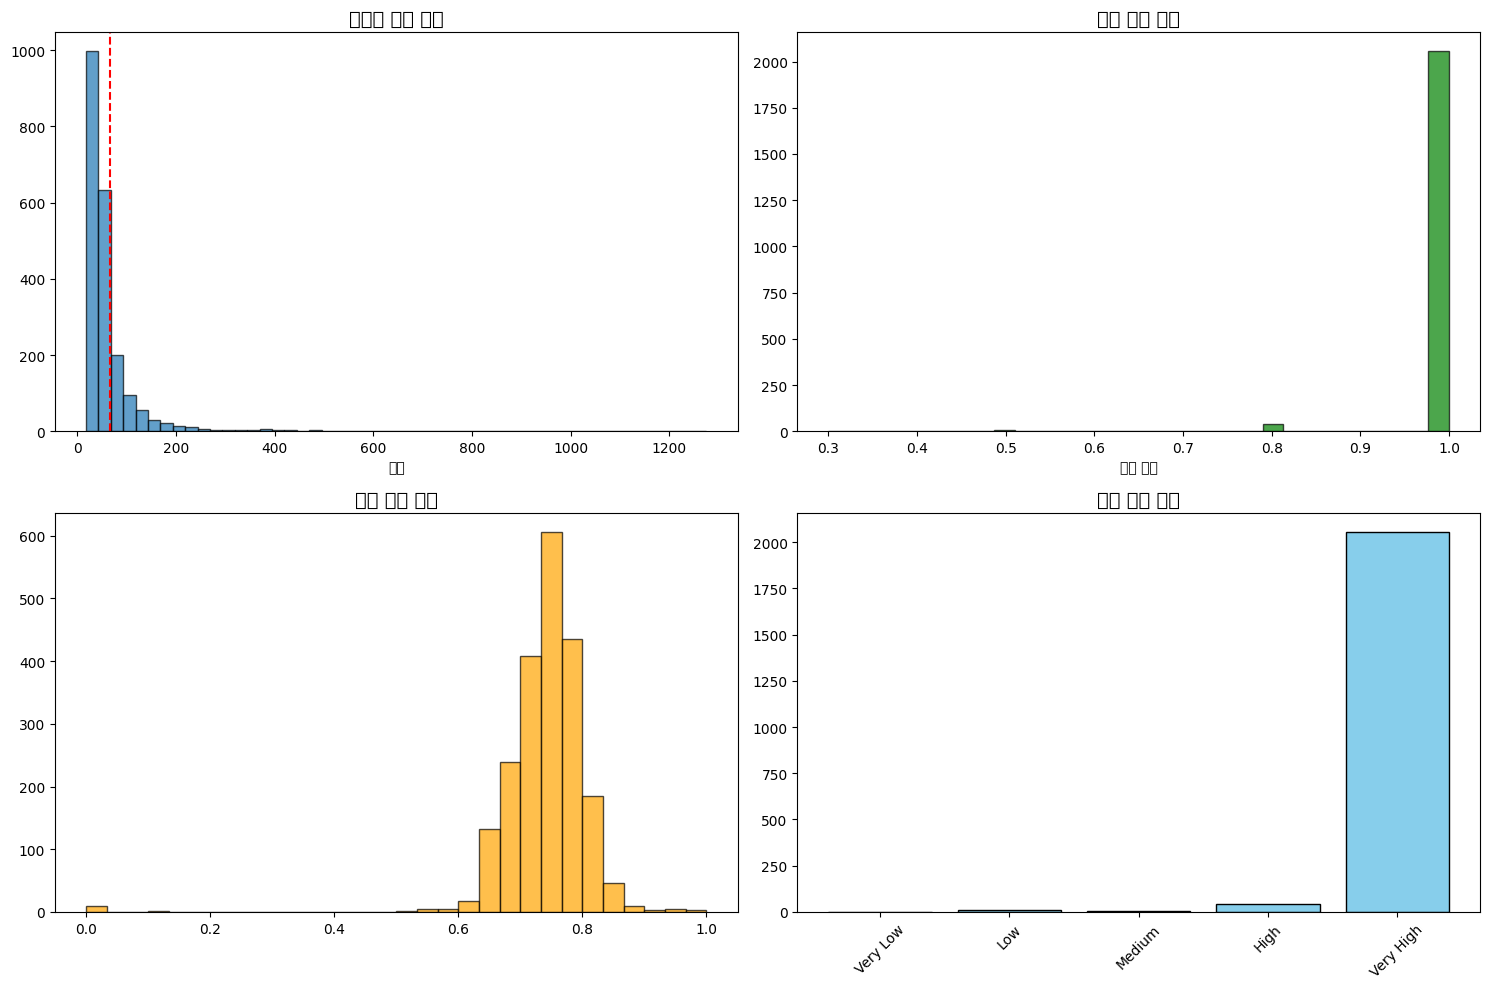

✅ 시각화 완료


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 길이 분포
axes[0, 0].hist(df_processed['length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('텍스트 길이 분포', fontsize=14)
axes[0, 0].set_xlabel('길이')
axes[0, 0].axvline(df_processed['length'].mean(), color='red', linestyle='--')

# 품질 점수
axes[0, 1].hist(df_processed['quality_score'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('품질 점수 분포', fontsize=14)
axes[0, 1].set_xlabel('품질 점수')

# 한글 비율
axes[1, 0].hist(df_processed['korean_ratio'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('한글 비율 분포', fontsize=14)

# 품질 등급
grade_counts = df_processed['quality_grade'].value_counts().sort_index()
axes[1, 1].bar(range(len(grade_counts)), grade_counts.values, color='skyblue', edgecolor='black')
axes[1, 1].set_title('품질 등급 분포', fontsize=14)
axes[1, 1].set_xticks(range(len(grade_counts)))
axes[1, 1].set_xticklabels(grade_counts.index, rotation=45)

plt.tight_layout()
plt.show()

print("✅ 시각화 완료")

In [ ]:
sample_size = min(CONFIG['logging']['sample_size'], len(df_processed))
sample_df = df_processed.sample(n=sample_size, random_state=42)[[
    'raw_text', 'clean_text', 'flags', 'quality_score'
]]

sample_df['changed'] = (sample_df['raw_text'] != sample_df['clean_text'])

print(f"변경: {sample_df['changed'].sum()} / {sample_size}")

# 변경된 것만 10개 출력
changed = sample_df[sample_df['changed']].head(10)
for idx, row in changed.iterrows():
    print(f"\n원문: {row['raw_text'][:80]}")
    print(f"정제: {row['clean_text'][:80]}")
    print(f"품질: {row['quality_score']:.3f}")
    print("-" * 80)

변경: 69 / 200

원문: 조아요! 발림성과 보습도 아주 좋습니다!
잘 산거 같아요 꿀
정제: 조아요! 발림성과 보습도 아주 좋습니다! 잘 산거 같아요 꿀
품질: 1.000
--------------------------------------------------------------------------------

원문: 아누아 기둥템!!!💙너무 잘쓰고 있고
환절기에도 사용하기에도 넘무좋고
좋긴좋은데 펌프형으로 만들면 위생적으로 더 좋을 것 같아욤
정제: 아누아 기둥템 너무 잘쓰고 있고 환절기에도 사용하기에도 넘무좋고 좋긴좋은데 펌프형으로 만들면 위생적으로 더 좋을 것 같아욤
품질: 1.000
--------------------------------------------------------------------------------

원문: 아누아 피디알엔 히알루론산 수분크림 한달사용후기 🩵

광고를 많이보기도했고 순위에 있어서 궁금해서 사봤는데 써보니 좋아서 또 재구매 했어요ㅎ
정제: 아누아 피디알엔 히알루론산 수분크림 한달사용후기 🩵 광고를 많이보기도했고 순위에 있어서 궁금해서 사봤는데 써보니 좋아서 또 재구매 했어요ㅎㅎ 튜
품질: 1.000
--------------------------------------------------------------------------------

원문: 원래 끈적 거리고 무거운 제형의 수분크림은 선호 하지 않는데 아누아 수분크림은 끈적임이 없고 흡수가 잘 되서 좋더라고요!얼굴에 되게 가볍게 느껴
정제: 원래 끈적 거리고 무거운 제형의 수분크림은 선호 하지 않는데 아누아 수분크림은 끈적임이 없고 흡수가 잘 되서 좋더라고요!얼굴에 되게 가볍게 느껴
품질: 1.000
--------------------------------------------------------------------------------

원문: 사용 전이에요. 앰플+크림 구성.구매할 껄
살짝 후회 합니다
정제: 사용 전이에요. 앰플+크

# 문법검사기 추가사용 (외부 라이브러리)

In [ ]:
# ========================================
# 후처리 1: 단일 자음/모음 완전 제거
# ========================================
def remove_single_jamo_completely(text):
    """단일 자음/모음 완전 제거 (ㅋ, ㅎ, ㅠ 등)"""
    if pd.isna(text) or text == '':
        return text

    # 모든 한글 자음 (ㄱ-ㅎ)
    consonants = 'ㄱㄲㄳㄴㄵㄶㄷㄸㄹㄺㄻㄼㄽㄾㄿㅀㅁㅂㅃㅄㅅㅆㅇㅈㅉㅊㅋㅌㅍㅎ'

    # 모든 한글 모음 (ㅏ-ㅣ)
    vowels = 'ㅏㅐㅑㅒㅓㅔㅕㅖㅗㅘㅙㅚㅛㅜㅝㅞㅟㅠㅡㅢㅣ'

    # 모든 자음/모음 제거
    for char in consonants + vowels:
        text = text.replace(char, '')

    # 연속 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print("단일 자음/모음 제거 중...")
df_processed['clean_text'] = df_processed['clean_text'].apply(remove_single_jamo_completely)
print("✅ 완료")


# ========================================
# 후처리 2: 특수문자 이모티콘 완전 제거
# ========================================
def remove_special_emoticons(text):
    """특수문자로 만든 이모티콘 제거 (*^^*), (╯°□°)╯ 등"""
    if pd.isna(text) or text == '':
        return text

    # 괄호 안에 특수문자만 있는 패턴 제거
    # 예: (*^^*), (╯°□°)╯, (´･ω･`), ɢ०ᵒᒄ 등
    text = re.sub(r'\([^가-힣a-zA-Z0-9\s]{1,20}\)', '', text)
    text = re.sub(r'\[[^가-힣a-zA-Z0-9\s]{1,20}\]', '', text)
    text = re.sub(r'\{[^가-힣a-zA-Z0-9\s]{1,20}\}', '', text)

    # 특수문자 연속 (3개 이상) 제거
    # 예: ･*:⋆゜, ･･･, ~~~, ━━━
    text = re.sub(r'[^\w\s가-힣]{3,}', '', text, flags=re.UNICODE)

    # 이모티콘 패턴들
    emoticon_patterns = [
        r'[><]_*[><]',           # >_<, ><
        r'[oOㅇ][._-]*[oOㅇ]',   # o.o, O_O
        r'T[._]T',                # T.T, T_T
        r'[;:=][\'"-]*[\)\]\(D]', # :), ;-), :D
        r'[\)\]\(D][\'"-]*[;:=]', # reverse
        r'\^[._-]*\^',           # ^_^, ^^
        r'[*][_^-]*[*]',         # *_*, *^*
        r'¯\\\_\(ツ\)_/¯',       # shrug
        r'ʕ•ᴥ•ʔ',                # bear
    ]

    for pattern in emoticon_patterns:
        text = re.sub(pattern, '', text)

    # 특수 유니코드 문자 제거 (장식용 문자들)
    # 예: ゜, ⋆, ･, ᵒ, ʳ, ᐢ, ⁱ 등
    text = re.sub(r'[^\w\s가-힣.,!?\-]', '', text, flags=re.UNICODE)

    # 연속 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print("특수문자 이모티콘 제거 중...")
df_processed['clean_text'] = df_processed['clean_text'].apply(remove_special_emoticons)
print("✅ 완료")


# ========================================
# 후처리 3: py-hanspell 문법 교정
# ========================================
from hanspell import spell_checker
from tqdm.auto import tqdm
import time

def correct_grammar(text):
    """py-hanspell로 맞춤법/띄어쓰기 교정"""
    if pd.isna(text) or text == '' or len(text) < 10:
        return text

    # 500자 제한
    if len(text) > 500:
        text = text[:500]

    # 3번 재시도
    for attempt in range(3):
        try:
            result = spell_checker.check(text)
            return result.checked
        except Exception as e:
            if attempt < 2:
                time.sleep(1)
                continue
            else:
                # 실패하면 원본 반환
                return text

    return text


print("\n" + "="*80)
print("🔧 py-hanspell 문법 교정 시작")
print("="*80)
print(f"총 {len(df_processed):,}개 처리\n")

# tqdm 진행률
tqdm.pandas(desc="문법 교정")
df_processed['clean_text'] = df_processed['clean_text'].progress_apply(correct_grammar)

changed_count = (df_processed['raw_text'] != df_processed['clean_text']).sum()
print(f"\n✅ 완료: {changed_count:,}개 변경")


# ========================================
# 후처리 4: 최종 정리
# ========================================
def final_cleanup(text):
    """최종 정리 - 연속 공백, 불필요한 문장부호 등"""
    if pd.isna(text) or text == '':
        return text

    # 연속된 마침표/느낌표/물음표
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)

    # 연속 공백
    text = re.sub(r'\s+', ' ', text)

    # 앞뒤 공백
    text = text.strip()

    return text


print("\n최종 정리 중...")
df_processed['clean_text'] = df_processed['clean_text'].apply(final_cleanup)
print("✅ 완료")


# ========================================
# 결과 확인
# ========================================
print("\n" + "="*80)
print("📊 후처리 결과 확인 (변경된 샘플 10개)")
print("="*80)

sample = df_processed[df_processed['raw_text'] != df_processed['clean_text']].head(10)

for idx, row in sample.iterrows():
    print(f"\n원문: {row['raw_text'][:100]}")
    print(f"정제: {row['clean_text'][:100]}")
    print("-" * 80)


# ========================================
# 품질 점수 재계산
# ========================================
print("\n품질 점수 재계산 중...")

stats = compute_text_stats(df_processed['clean_text'])

quality_scores = []
for idx, row in stats.iterrows():
    score = 1.0

    if row['length'] < 10:
        score *= 0.3
    elif row['length'] < 20:
        score *= 0.6
    elif row['length'] < 30:
        score *= 0.8

    if row['korean_ratio'] < 0.3:
        score *= 0.5
    elif row['korean_ratio'] < 0.5:
        score *= 0.7

    if row['special_ratio'] > 0.3:
        score *= 0.6
    elif row['special_ratio'] > 0.2:
        score *= 0.8

    if row['length'] == 0:
        score = 0.0

    quality_scores.append(min(1.0, score))

df_processed['quality_score'] = quality_scores
df_processed['length'] = stats['length']
df_processed['korean_ratio'] = stats['korean_ratio']

print(f"✅ 평균 품질: {df_processed['quality_score'].mean():.3f}")


# ========================================
# 최종 저장
# ========================================
product_number = list(uploaded.keys())[0].split(".")[0]
print(product_number) # 제품 번호

output_file = f'reviews_cleaned_product{product_number}.csv'
df_processed.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n✅ 저장: {output_file}")
print(f"총 {len(df_processed):,}행")

# 다운로드
from google.colab import files
files.download(output_file)

단일 자음/모음 제거 중...
✅ 완료
특수문자 이모티콘 제거 중...
✅ 완료

🔧 py-hanspell 문법 교정 시작
총 2,110개 처리



문법 교정:   0%|          | 0/2110 [00:00<?, ?it/s]


✅ 완료: 1,143개 변경

최종 정리 중...
✅ 완료

📊 후처리 결과 확인 (변경된 샘플 10개)

원문: 요 아이는 뭔가 수분을 채워지는 느낌보다는 pdrn 느낌이라
유분기가 엄청 많고 유분막을 형성해주는 느낌이에요..

그래서 그런지 광채하나는기가막혀요
정제: 요 아이는 뭔가 수분을 채워지는 느낌보다는 pdrn 느낌이라 유분기가 엄청 많고 유분막을 형성해주는 느낌이에요. 그래서 그런지 광채하나는기가막혀요
--------------------------------------------------------------------------------

원문: 지복합성 피부라 토너 세럼 잘 해주면 마무리 크림단계 때 이걸로도 충분해요.
PDRN은 잘 모르겠고, 세라마이드가 약간 들어가 있는거 같은데 비타민c 랑 궁합이 좋다고 해서 세럼
정제: 지복합성 피부라 토너 세럼 잘 해주면 마무리 크림단계 때 이걸로도 충분해요. PDRN은 잘 모르겠고, 세라마이드가 약간 들어가 있는거 같은데 비타민c 랑 궁합이 좋다고 해서 세럼 
--------------------------------------------------------------------------------

원문: 무난하게 사용하기 ㄱㅊ음
화장 전에 살짝 바르면 좋아용
기획세트 구성 좋았어요
정제: 무난하게 사용하기 음 화장 전에 살짝 바르면 좋아용 기획세트 구성 좋았어요
--------------------------------------------------------------------------------

원문: 이거 너무너무 좋아요!!ㅎㅎ 완전 촉촉하고 진짜 최고에요! 얼굴에 바로 물 직빵으로 흡수시키는것처럼 너무너무 촉촉하고 좋아용ㅎㅎ 최고입니다요
정제: 이거 너무너무 좋아요! 완전 촉촉하고 진짜 최고에요! 얼굴에 바로 물 직빵으로 흡수시키는것처럼 너무너무 촉촉하고 좋아용 최고입니다요
-------------------------------------------------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_processed

,product_name,product_type,price,날짜,별점,스킨타입,태그,리뷰내용,raw_text,clean_text,quality_score,length,korean_ratio,special_ratio,quality_grade,flags
0,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2026.01.25,4점,NaN,한달이상사용,요 아이는 뭔가 수분을 채워지는 느낌보다는 pdrn 느낌이라\r\n유분기가 엄청 많고 유분막을 형성해주는 느낌이에요..\r\n\r\n그래서 그런지 광채하나는기가막혀요,요 아이는 뭔가 수분을 채워지는 느낌보다는 pdrn 느낌이라\r\n유분기가 엄청 많고 유분막을 형성해주는 느낌이에요..\r\n\r\n그래서 그런지 광채하나는기가막혀요,요 아이는 뭔가 수분을 채워지는 느낌보다는 pdrn 느낌이라 유분기가 엄청 많고 유분막을 형성해주는 느낌이에요. 그래서 그런지 광채하나는기가막혀요,1.0,81,0.740741,0.024390,Very High,"emoji_removed,repeat_normalized,typo_corrected"
1,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2026.01.25,5점,NaN,NaN,"지복합성 피부라 토너 세럼 잘 해주면 마무리 크림단계 때 이걸로도 충분해요.\r\nPDRN은 잘 모르겠고, 세라마이드가 약간 들어가 있는거 같은데 비타민c 랑 궁합이 좋다고...","지복합성 피부라 토너 세럼 잘 해주면 마무리 크림단계 때 이걸로도 충분해요.\r\nPDRN은 잘 모르겠고, 세라마이드가 약간 들어가 있는거 같은데 비타민c 랑 궁합이 좋다고...","지복합성 피부라 토너 세럼 잘 해주면 마무리 크림단계 때 이걸로도 충분해요. PDRN은 잘 모르겠고, 세라마이드가 약간 들어가 있는거 같은데 비타민c 랑 궁합이 좋다고 해서...",1.0,139,0.690647,0.028571,Very High,"emoji_removed,repeat_normalized,typo_corrected"
2,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2026.01.25,5점,NaN,NaN,세럼도 세럼인데 전 이 수분크림이 너무 마음에 듭니다 수분막 싸악 씌운 이 피부가 너무 졸아요,세럼도 세럼인데 전 이 수분크림이 너무 마음에 듭니다 수분막 싸악 씌운 이 피부가 너무 졸아요,세럼도 세럼인데 전 이 수분크림이 너무 마음에 듭니다 수분막 싸악 씌운 이 피부가 너무 졸아요,1.0,52,0.730769,0.000000,Very High,"emoji_removed,repeat_normalized,typo_corrected"
3,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2026.01.25,4점,"건성, 쿨톤, 트러블, 홍조",한달이상사용,무난하게 사용하기 ㄱㅊ음\r\n화장 전에 살짝 바르면 좋아용\r\n기획세트 구성 좋았어요,무난하게 사용하기 ㄱㅊ음\r\n화장 전에 살짝 바르면 좋아용\r\n기획세트 구성 좋았어요,무난하게 사용하기 음 화장 전에 살짝 바르면 좋아용 기획세트 구성 좋았어요,1.0,41,0.756098,0.046512,Very High,"emoji_removed,repeat_normalized,typo_corrected"
4,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2026.01.25,5점,"복합성, 겨울쿨톤, 모공",한달이상사용,항상 두고두고 쟁여두고 쓰는 꿀템! 이거 없던때로 못돌아가요,항상 두고두고 쟁여두고 쓰는 꿀템! 이거 없던때로 못돌아가요,항상 두고두고 쟁여두고 쓰는 꿀템! 이거 없던때로 못돌아가요,1.0,33,0.757576,0.030303,Very High,"emoji_removed,repeat_normalized,typo_corrected"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2105,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2025.08.01,4점,"민감성, 웜톤, 잡티, 트러블",NaN,🌟🌟한줄 리뷰평🌟🌟\r\n무겁지않게 얇게발림! 다만 손이 잘 안감,🌟🌟한줄 리뷰평🌟🌟\r\n무겁지않게 얇게발림! 다만 손이 잘 안감,한줄 리뷰평 무겁지않게 얇게발림! 다만 손이 잘 안감,0.8,29,0.724138,0.034483,High,"emoji_removed,repeat_normalized,typo_corrected"
2106,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2025.08.01,4점,NaN,한달이상사용,"발림성 좋고, 수분감 낭낭한데 수부지인 제 피부 기준 과하지도 않아서 다 좋았는데 ..!! 제 피부엔 안 맞는지 울긋불긋 올라오더라고요 .. 너모 아쉬움 🥹 그래서 언니 줬...","발림성 좋고, 수분감 낭낭한데 수부지인 제 피부 기준 과하지도 않아서 다 좋았는데 ..!! 제 피부엔 안 맞는지 울긋불긋 올라오더라고요 .. 너모 아쉬움 🥹 그래서 언니 줬...","발림성 좋고, 수분감 낭낭한데 수부지인 제 피부 기준 과하지도 않아서 다 좋았는데 제 피부엔 안 맞는지 울긋불긋 올라오더라고요 . 너모 아쉬움 그래서 언니 줬는데 맘에 든다...",1.0,134,0.708955,0.083333,Very High,"emoji_removed,repeat_normalized,typo_corrected"
2107,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2025.08.01,5점,"복합성, 웜톤, 각질, 블랙헤드",NaN,촉촉하고 자기전 얼굴에 듬뿍 얹고 자도 괜찮은거 같다고 느꼈습니다,촉촉하고 자기전 얼굴에 듬뿍 얹고 자도 괜찮은거 같다고 느꼈습니다,촉촉하고 자기전 얼굴에 듬뿍 얹고 자도 괜찮은거 같다고 느꼈습니다,1.0,36,0.777778,0.000000,Very High,"emoji_removed,repeat_normalized,typo_corrected"
2108,아누아 피디알엔 히알루론산 100 수분크림 60ml 기획 2입,크림,"29,500",2025.08.01,5점,NaN,NaN,저녁마다 바르고 잡니다.\r\n발림성도 좋아요\r\n다쓰고 또 주문하고 지인들에게 강추,저녁마다 바르고 잡니다.\r\n발림성도 좋아요\r\n다쓰고 또 주문하고 지인들에게 강추,저녁마다 바르고 잡니다. 발림성도 좋아요 다쓰고 또 주문하고 지인들에게 강추,1.0,42,0.761905,0.023810,Very High,"emoji_removed,repeat_normalized,typo_corrected"
